In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
print("GPU disponible:", torch.cuda.is_available())
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

GPU disponible: False


In [4]:
IMG_HEIGHT   = 112
IMG_WIDTH    = 92
IMG_CHANNELS = 1
NUM_CLASSES  = 40
BATCH_SIZE   = 16
EPOCHS       = 50
LEARNING_RATE = 1e-3

DATASET_PATH = "dataset/"
TRAIN_PATH   = os.path.join(DATASET_PATH, "Training")
TEST_PATH    = os.path.join(DATASET_PATH, "Testing")

In [27]:
class ORLDataset(Dataset):
    def __init__(self, base_path, transform=None):
        self.samples   = []   # lista de (ruta, label)
        self.transform = transform

        subject_folders = sorted(
            [d for d in os.listdir(base_path)
             if os.path.isdir(os.path.join(base_path, d))],
            key=lambda x: int(x[1:])
        )

        print(f"\nCargando desde : {base_path}")
        print(f"Sujetos encontrados: {len(subject_folders)}")

        for label_idx, subject in enumerate(subject_folders):
            subject_path = os.path.join(base_path, subject)
            img_files = [f for f in os.listdir(subject_path)
             if f.lower().endswith(('.pgm', '.png'))]
            for img_file in img_files:
                self.samples.append(
                    (os.path.join(subject_path, img_file), label_idx)
                )

        print(f"Total imágenes  : {len(self.samples)}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        img = Image.open(img_path).convert('L')   # escala de grises
        if self.transform:
            img = self.transform(img)
        return img, label

In [6]:
# Augmentation solo para entrenamiento
train_transform = transforms.Compose([
    transforms.Resize((IMG_HEIGHT, IMG_WIDTH)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ToTensor(),                        # (1, 112, 92) rango [0,1]
    transforms.Normalize(mean=[0.5], std=[0.5])   # rango [-1, 1]
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_HEIGHT, IMG_WIDTH)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

train_dataset = ORLDataset(TRAIN_PATH, transform=train_transform)
test_dataset  = ORLDataset(TEST_PATH,  transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=0)

print(f"\nBatches train : {len(train_loader)}")
print(f"Batches test  : {len(test_loader)}")


Cargando desde : dataset/Training
Sujetos encontrados: 40
Total imágenes  : 360

Cargando desde : dataset/Testing
Sujetos encontrados: 40
Total imágenes  : 40

Batches train : 23
Batches test  : 3


In [7]:
class ConvBN(nn.Module):
    def __init__(self, in_c, out_c, kernel, stride=1, padding=1, activation=True):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_c, out_c, kernel, stride=stride,
                      padding=padding, bias=False),
            nn.BatchNorm2d(out_c),
            nn.ReLU6(inplace=True) if activation else nn.Identity()
        )
    def forward(self, x):
        return self.block(x)


class DepthwiseBN(nn.Module):
    def __init__(self, channels, stride=1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(channels, channels, 3, stride=stride,
                      padding=1, groups=channels, bias=False),
            nn.BatchNorm2d(channels),
            nn.ReLU6(inplace=True)
        )
    def forward(self, x):
        return self.block(x)


class Bottleneck(nn.Module):
    def __init__(self, in_c, out_c, stride, expansion):
        super().__init__()
        expanded = in_c * expansion
        self.use_residual = (stride == 1 and in_c == out_c)

        layers_list = []
        if expansion != 1:
            layers_list.append(ConvBN(in_c, expanded, 1, padding=0))
        layers_list += [
            DepthwiseBN(expanded, stride=stride),
            nn.Conv2d(expanded, out_c, 1, bias=False),
            nn.BatchNorm2d(out_c)
        ]
        self.block = nn.Sequential(*layers_list)

    def forward(self, x):
        out = self.block(x)
        if self.use_residual:
            out = out + x
        return out

In [9]:
class MobileFaceNet(nn.Module):
    """
    MobileFaceNet adaptado para ORL Dataset
    Input : (B, 1, 112, 92) — escala de grises
    Output: (B, num_classes)
    """
    def __init__(self, num_classes=NUM_CLASSES, embedding_dim=128):
        super().__init__()

        # ---- Stem ----
        self.stem = nn.Sequential(
            ConvBN(1, 64, 3, stride=2, padding=1),    # → (56, 46)
            DepthwiseBN(64, stride=1)
        )

        # ---- Bottleneck blocks ----
        # (expansion, out_channels, repeticiones, stride_primera)
        cfg = [
            (2,  64,  5, 2),   # → (28, 23)
            (4, 128,  1, 2),   # → (14, 12)
            (2, 128,  6, 1),   # → (14, 12)
            (4, 128,  1, 2),   # → ( 7,  6)
            (2, 128,  2, 1),   # → ( 7,  6)
        ]

        blocks = []
        in_c = 64
        for t, c, n, s in cfg:
            for i in range(n):
                stride = s if i == 0 else 1
                blocks.append(Bottleneck(in_c, c, stride, t))
                in_c = c
        self.bottlenecks = nn.Sequential(*blocks)

        # ---- Conv 1×1 ----
        self.conv_512 = ConvBN(128, 512, 1, padding=0)   # → (7, 6, 512)
        self.gdconv = nn.Sequential(
            nn.Conv2d(512, 512, kernel_size=(7, 6),
            groups=512, bias=False),       
            nn.GroupNorm(num_groups=32, num_channels=512) 
        )

        # ---- Embedding 1×1 ----
        self.embedding = nn.Sequential(
            nn.Conv2d(512, embedding_dim, 1, bias=False),
            nn.GroupNorm(num_groups=8, num_channels=embedding_dim),
            nn.Flatten()                                  # → 128-D
        )

        # ---- Clasificador ----
        self.classifier = nn.Linear(embedding_dim, num_classes)

    def forward(self, x):
        x = self.stem(x)
        x = self.bottlenecks(x)
        x = self.conv_512(x)
        x = self.gdconv(x)
        x = self.embedding(x)
        return self.classifier(x)


model = MobileFaceNet().to(DEVICE)
print(model)

# Verificar shapes con un batch ficticio
dummy = torch.zeros(1, 1, IMG_HEIGHT, IMG_WIDTH).to(DEVICE)
out   = model(dummy)
print(f"\nShape de salida con input (1,1,112,92): {out.shape}")  # → (1, 40)

MobileFaceNet(
  (stem): Sequential(
    (0): ConvBN(
      (block): Sequential(
        (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (2): ReLU6(inplace=True)
      )
    )
    (1): DepthwiseBN(
      (block): Sequential(
        (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=64, bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (2): ReLU6(inplace=True)
      )
    )
  )
  (bottlenecks): Sequential(
    (0): Bottleneck(
      (block): Sequential(
        (0): ConvBN(
          (block): Sequential(
            (0): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
            (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
            (2): ReLU6(inplace=True)
          )
     

In [13]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min', 
    factor=0.5,
    patience=5, 
    min_lr=1e-6, 
)



In [14]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        correct    += (outputs.argmax(1) == labels).sum().item()
        total      += imgs.size(0)
    return total_loss / total, correct / total


def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            outputs    = model(imgs)
            loss       = criterion(outputs, labels)
            total_loss += loss.item() * imgs.size(0)
            correct    += (outputs.argmax(1) == labels).sum().item()
            total      += imgs.size(0)
    return total_loss / total, correct / total


history = {'train_loss': [], 'train_acc': [],
           'val_loss':   [], 'val_acc':   []}

best_val_acc   = 0.0
patience_count = 0
EARLY_STOP     = 10

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    va_loss, va_acc = evaluate(model, test_loader, criterion)

    scheduler.step(va_loss)
    current_lr = optimizer.param_groups[0]['lr']  # ← log manual del LR

    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc)
    history['val_loss'].append(va_loss)
    history['val_acc'].append(va_acc)

    print(f"Época {epoch:02d}/{EPOCHS} | "
          f"Train Loss: {tr_loss:.4f}  Acc: {tr_acc*100:.2f}% | "
          f"Val Loss: {va_loss:.4f}  Acc: {va_acc*100:.2f}% | "
          f"LR: {current_lr:.2e}")  # ← LR incluido en el print

    if va_acc > best_val_acc:
        best_val_acc = va_acc
        torch.save(model.state_dict(), "best_mobilefacenet_orl.pth")
        print(f"  ✓ Mejor modelo guardado (val_acc={best_val_acc*100:.2f}%)")
        patience_count = 0
    else:
        patience_count += 1
        if patience_count >= EARLY_STOP:
            print(f"\nEarly stopping en época {epoch}")
            break

print(f"\nMejor Val Accuracy: {best_val_acc*100:.2f}%")

Época 01/50 | Train Loss: 3.8635  Acc: 3.06% | Val Loss: 3.9003  Acc: 2.50% | LR: 1.00e-03
  ✓ Mejor modelo guardado (val_acc=2.50%)
Época 02/50 | Train Loss: 3.1737  Acc: 13.61% | Val Loss: 3.6618  Acc: 7.50% | LR: 1.00e-03
  ✓ Mejor modelo guardado (val_acc=7.50%)
Época 03/50 | Train Loss: 2.3677  Acc: 33.89% | Val Loss: 1.9951  Acc: 52.50% | LR: 1.00e-03
  ✓ Mejor modelo guardado (val_acc=52.50%)
Época 04/50 | Train Loss: 1.7300  Acc: 59.72% | Val Loss: 1.4274  Acc: 75.00% | LR: 1.00e-03
  ✓ Mejor modelo guardado (val_acc=75.00%)
Época 05/50 | Train Loss: 1.1553  Acc: 77.78% | Val Loss: 1.0638  Acc: 80.00% | LR: 1.00e-03
  ✓ Mejor modelo guardado (val_acc=80.00%)
Época 06/50 | Train Loss: 0.8167  Acc: 88.33% | Val Loss: 0.7296  Acc: 85.00% | LR: 1.00e-03
  ✓ Mejor modelo guardado (val_acc=85.00%)
Época 07/50 | Train Loss: 0.5224  Acc: 93.06% | Val Loss: 0.4951  Acc: 92.50% | LR: 1.00e-03
  ✓ Mejor modelo guardado (val_acc=92.50%)
Época 08/50 | Train Loss: 0.3531  Acc: 96.67% | Val L

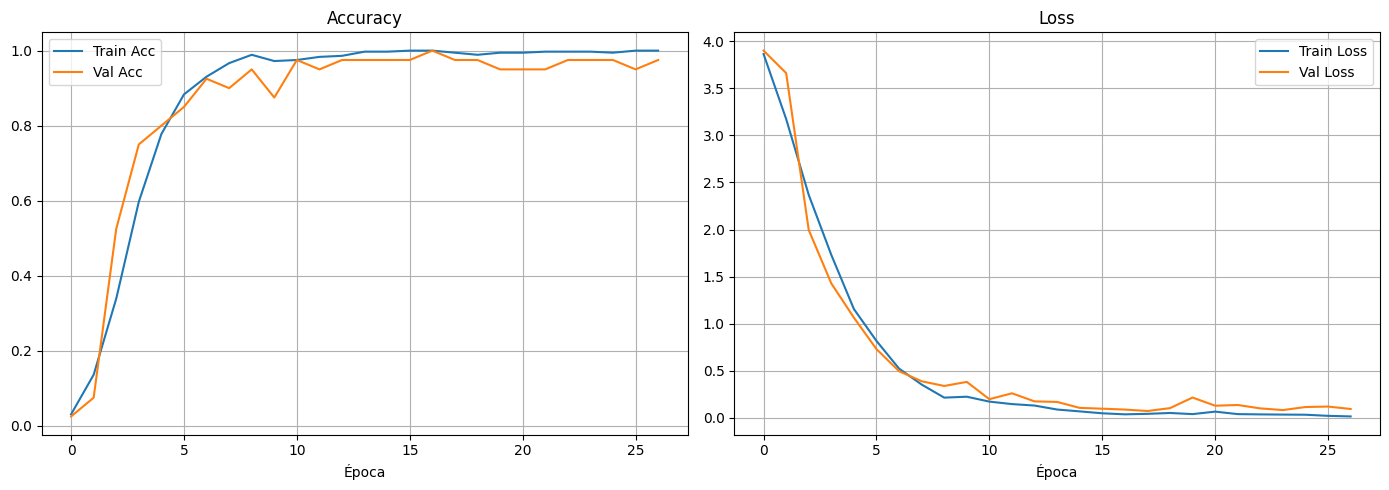

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history['train_acc'], label='Train Acc')
axes[0].plot(history['val_acc'],   label='Val Acc')
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Época')
axes[0].legend(); axes[0].grid(True)

axes[1].plot(history['train_loss'], label='Train Loss')
axes[1].plot(history['val_loss'],   label='Val Loss')
axes[1].set_title('Loss')
axes[1].set_xlabel('Época')
axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.show()

In [16]:
# Cargar mejor modelo
model.load_state_dict(torch.load("best_mobilefacenet_orl.pth",
                                  map_location=DEVICE))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(DEVICE)
        preds = model(imgs).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

print(f"\n{'='*40}")
print(f"  Test Accuracy: {(all_preds == all_labels).mean()*100:.2f}%")
print(f"{'='*40}\n")

print("Classification Report:")
print(classification_report(
    all_labels, all_preds,
    target_names=[f"s{i+1}" for i in range(NUM_CLASSES)]
))


  Test Accuracy: 100.00%

Classification Report:
              precision    recall  f1-score   support

          s1       1.00      1.00      1.00         1
          s2       1.00      1.00      1.00         1
          s3       1.00      1.00      1.00         1
          s4       1.00      1.00      1.00         1
          s5       1.00      1.00      1.00         1
          s6       1.00      1.00      1.00         1
          s7       1.00      1.00      1.00         1
          s8       1.00      1.00      1.00         1
          s9       1.00      1.00      1.00         1
         s10       1.00      1.00      1.00         1
         s11       1.00      1.00      1.00         1
         s12       1.00      1.00      1.00         1
         s13       1.00      1.00      1.00         1
         s14       1.00      1.00      1.00         1
         s15       1.00      1.00      1.00         1
         s16       1.00      1.00      1.00         1
         s17       1.00      1.

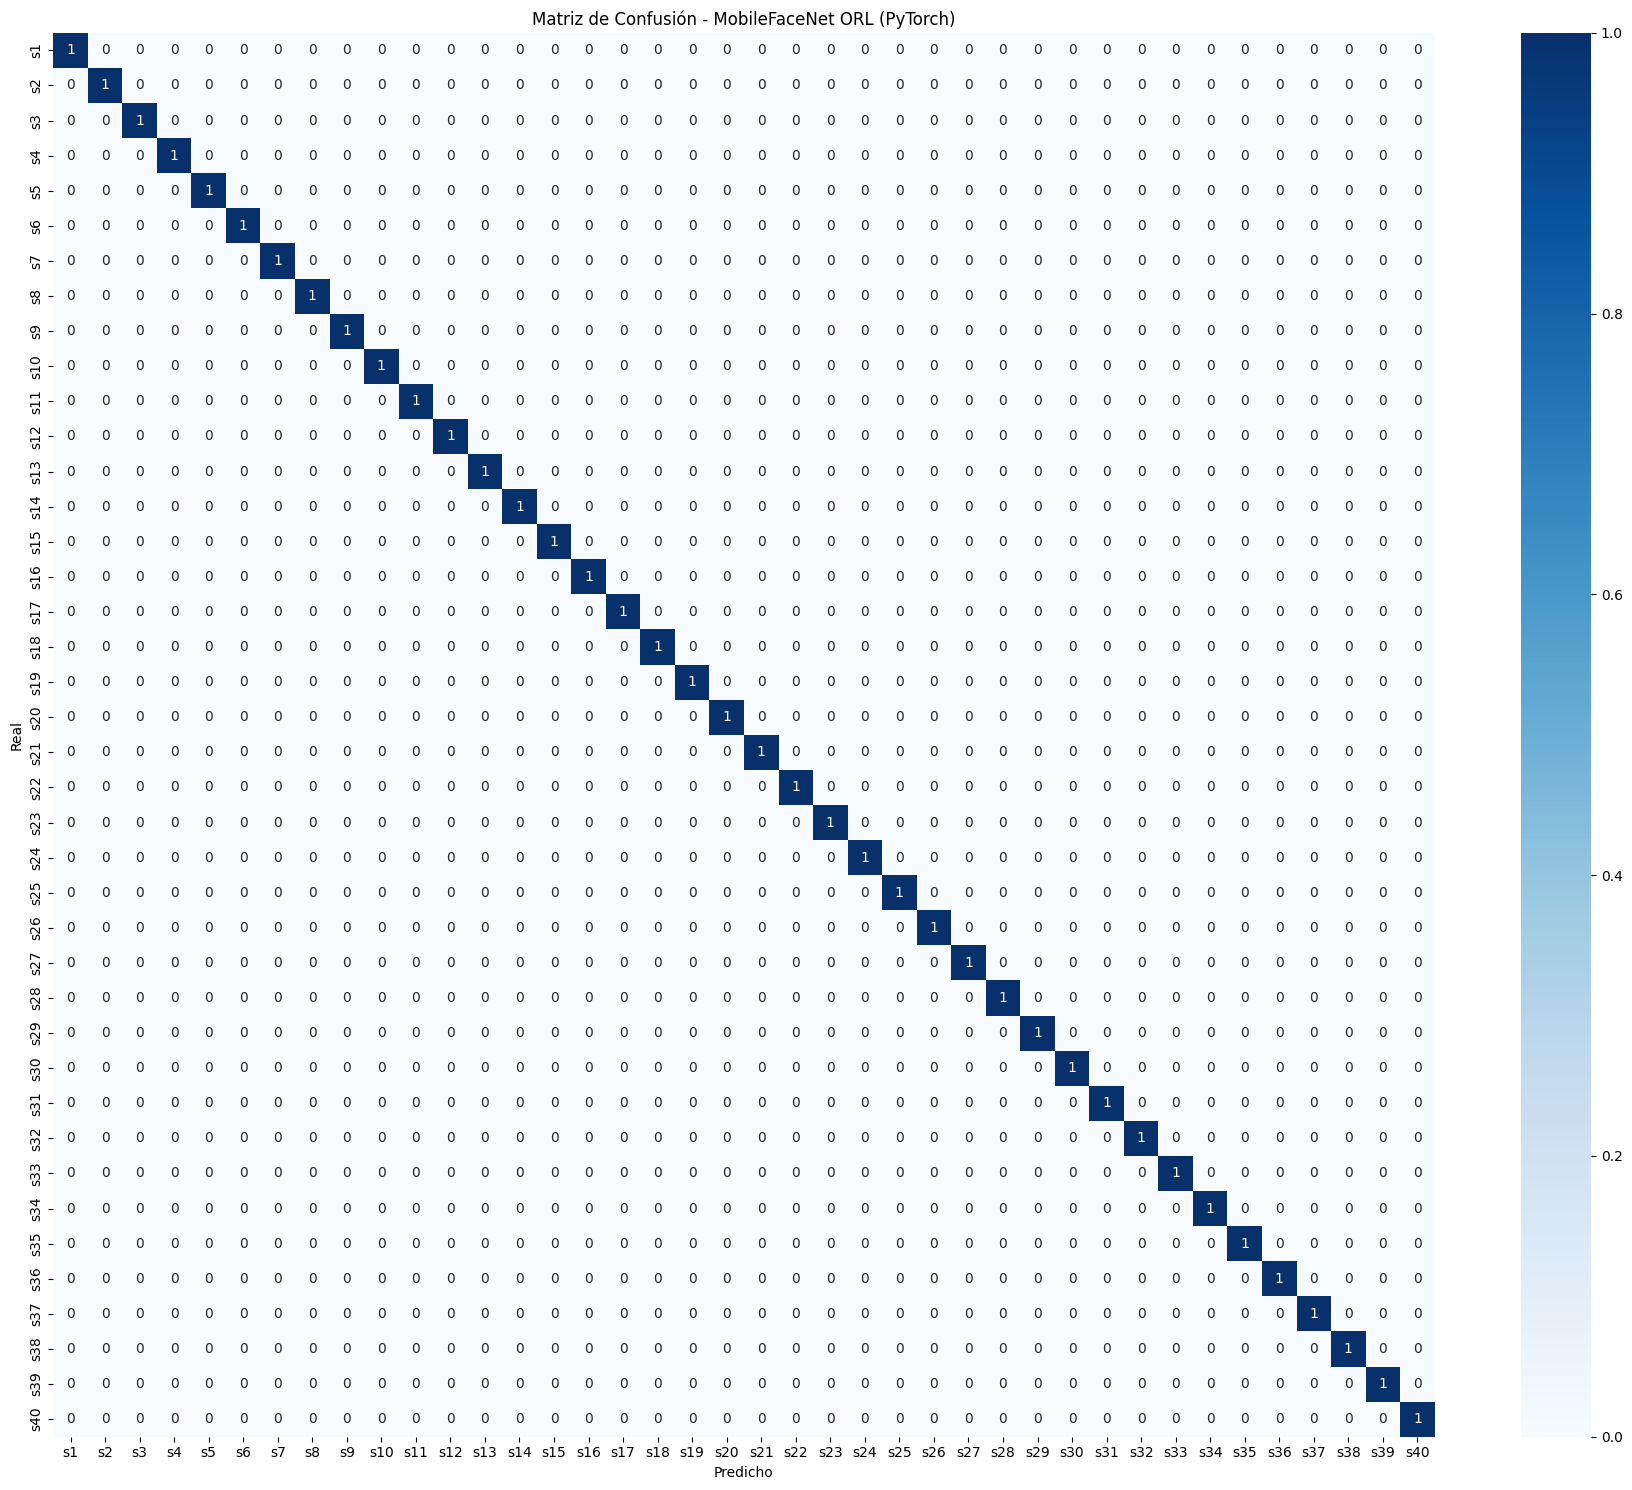

In [17]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(18, 15))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[f"s{i+1}" for i in range(NUM_CLASSES)],
            yticklabels=[f"s{i+1}" for i in range(NUM_CLASSES)])
plt.title('Matriz de Confusión - MobileFaceNet ORL (PyTorch)')
plt.ylabel('Real'); plt.xlabel('Predicho')
plt.tight_layout(); plt.show()

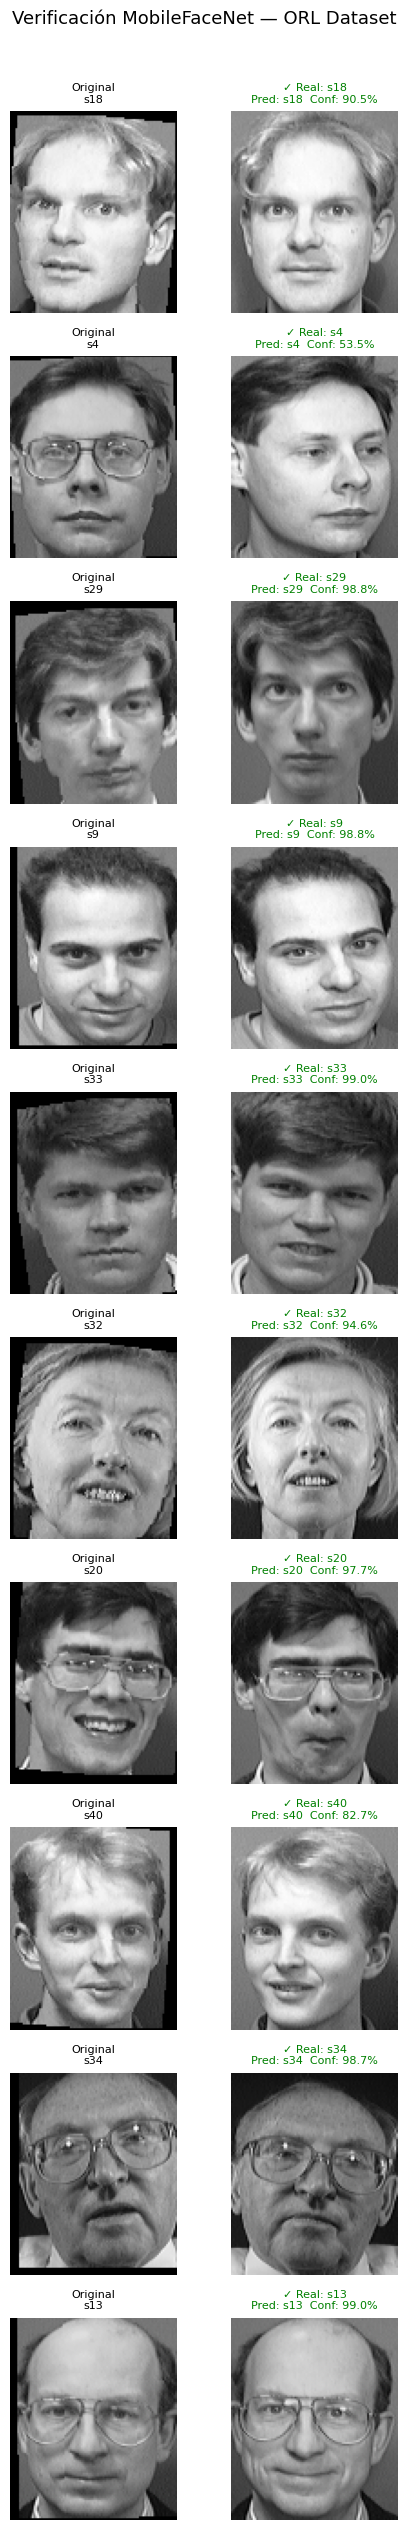


--- Resumen de verificación ---
Identificados correctamente : 40/40
Accuracy total              : 100.00%


In [18]:
def plot_verification(train_dataset, test_dataset, model, n=10):
    """
    Para cada sujeto de test muestra:
    - Imagen original (training, primera imagen del sujeto)
    - Imagen de test
    - Etiqueta real, predicción y confianza
    """
    model.eval()

    # Construir diccionario: label → primera imagen de entrenamiento
    train_reference = {}
    for img, label in train_dataset:
        if label not in train_reference:
            train_reference[label] = img

    # Seleccionar n sujetos aleatorios del test
    indices = np.random.choice(len(test_dataset), n, replace=False)

    fig, axes = plt.subplots(n, 2, figsize=(5, n * 2.5))
    fig.suptitle("Verificación MobileFaceNet — ORL Dataset", fontsize=13, y=1.01)

    with torch.no_grad():
        for row, idx in enumerate(indices):
            img_test, label = test_dataset[idx]

            # Predicción con confianza
            logits  = model(img_test.unsqueeze(0).to(DEVICE))
            probs   = torch.softmax(logits, dim=1)
            conf, pred = probs.max(1)
            pred    = pred.item()
            conf    = conf.item() * 100

            # Desnormalizar para visualizar
            def denorm(t):
                return (t.squeeze().cpu().numpy() * 0.5 + 0.5).clip(0, 1)

            img_train_show = denorm(train_reference[label])
            img_test_show  = denorm(img_test)

            correct = (pred == label)
            color   = 'green' if correct else 'red'
            symbol  = '✓' if correct else '✗'

            # ---- Columna izquierda: imagen de referencia (train) ----
            axes[row, 0].imshow(img_train_show, cmap='gray')
            axes[row, 0].set_title(f"Original\ns{label+1}", fontsize=8)
            axes[row, 0].axis('off')

            # ---- Columna derecha: imagen de test + resultado ----
            axes[row, 1].imshow(img_test_show, cmap='gray')
            axes[row, 1].set_title(
                f"{symbol} Real: s{label+1}\nPred: s{pred+1}  Conf: {conf:.1f}%",
                fontsize=8, color=color
            )
            axes[row, 1].axis('off')

    plt.tight_layout()
    plt.show()

    # Resumen numérico
    print("\n--- Resumen de verificación ---")
    correct_total = 0
    with torch.no_grad():
        for img_test, label in test_dataset:
            logits = model(img_test.unsqueeze(0).to(DEVICE))
            pred   = logits.argmax(1).item()
            if pred == label:
                correct_total += 1
    print(f"Identificados correctamente : {correct_total}/{len(test_dataset)}")
    print(f"Accuracy total              : {correct_total/len(test_dataset)*100:.2f}%")


plot_verification(train_dataset, test_dataset, model, n=10)

In [ ]:
CLAHE_TEST_PATH  = "dataset/CLAHE/Testing_CLAHE_escala4"
CLAHE_TRAIN_PATH = "dataset/CLAHE/Training_CLAHE_escala4"  # solo para referencia visual

# Cargar el mejor modelo guardado
model.load_state_dict(torch.load("best_mobilefacenet_orl.pth",
                                  map_location=DEVICE))
model.eval()
print("Modelo original cargado correctamente.")

Modelo original cargado correctamente.


In [28]:
# Transform idéntico al test original (sin augmentation)
clahe_transform = transforms.Compose([
    transforms.Resize((IMG_HEIGHT, IMG_WIDTH)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

clahe_test_dataset  = ORLDataset(CLAHE_TEST_PATH,  transform=clahe_transform)
clahe_train_dataset = ORLDataset(CLAHE_TRAIN_PATH, transform=clahe_transform)

clahe_test_loader = DataLoader(clahe_test_dataset, batch_size=BATCH_SIZE,
                                shuffle=False, num_workers=0)

print(f"Imágenes CLAHE test  cargadas: {len(clahe_test_dataset)}")
print(f"Imágenes CLAHE train cargadas: {len(clahe_train_dataset)}")


Cargando desde : dataset/CLAHE/Testing_CLAHE_escala4
Sujetos encontrados: 40
Total imágenes  : 40

Cargando desde : dataset/CLAHE/Training_CLAHE_escala4
Sujetos encontrados: 40
Total imágenes  : 360
Imágenes CLAHE test  cargadas: 40
Imágenes CLAHE train cargadas: 360


In [29]:
all_preds_clahe, all_labels_clahe, all_confs_clahe = [], [], []

model.eval()
with torch.no_grad():
    for imgs, labels in clahe_test_loader:
        imgs = imgs.to(DEVICE)
        logits = model(imgs)
        probs  = torch.softmax(logits, dim=1)
        conf, pred = probs.max(1)
        all_preds_clahe.extend(pred.cpu().numpy())
        all_labels_clahe.extend(labels.numpy())
        all_confs_clahe.extend(conf.cpu().numpy())

all_preds_clahe  = np.array(all_preds_clahe)
all_labels_clahe = np.array(all_labels_clahe)
all_confs_clahe  = np.array(all_confs_clahe)

acc_clahe = (all_preds_clahe == all_labels_clahe).mean() * 100

print(f"\n{'='*50}")
print(f"  Accuracy Original  (ORL)        : 100.00%")
print(f"  Accuracy Degradado (CLAHE x4)   : {acc_clahe:.2f}%")
print(f"  Caída de rendimiento            : {100.00 - acc_clahe:.2f}%")
print(f"{'='*50}")
print(f"\n  Confianza promedio : {all_confs_clahe.mean()*100:.2f}%")
print(f"  Confianza mínima   : {all_confs_clahe.min()*100:.2f}%")
print(f"  Confianza máxima   : {all_confs_clahe.max()*100:.2f}%")
print(f"  Desviación estándar: {all_confs_clahe.std()*100:.2f}%")

print("\nClassification Report (CLAHE x4):")
print(classification_report(
    all_labels_clahe, all_preds_clahe,
    target_names=[f"s{i+1}" for i in range(NUM_CLASSES)]
))


  Accuracy Original  (ORL)        : 100.00%
  Accuracy Degradado (CLAHE x4)   : 12.50%
  Caída de rendimiento            : 87.50%

  Confianza promedio : 39.13%
  Confianza mínima   : 17.33%
  Confianza máxima   : 81.78%
  Desviación estándar: 17.60%

Classification Report (CLAHE x4):
              precision    recall  f1-score   support

          s1       0.00      0.00      0.00         1
          s2       0.00      0.00      0.00         1
          s3       0.00      0.00      0.00         1
          s4       0.00      0.00      0.00         1
          s5       0.00      0.00      0.00         1
          s6       0.17      1.00      0.29         1
          s7       0.00      0.00      0.00         1
          s8       0.50      1.00      0.67         1
          s9       0.00      0.00      0.00         1
         s10       0.00      0.00      0.00         1
         s11       0.50      1.00      0.67         1
         s12       0.00      0.00      0.00         1
         s

c:\Users\LENOVO\Desktop\Universidad\Ciclo 8\Machine Learning\Mora_Abel_ML_Evaluacion1\Mora_Abel_face-recognition-ML\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\LENOVO\Desktop\Universidad\Ciclo 8\Machine Learning\Mora_Abel_ML_Evaluacion1\Mora_Abel_face-recognition-ML\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\LENOVO\Desktop\Universidad\Ciclo 8\Machine Learning\Mora_Abel_ML_Evaluacion1\Mora_Abel_face-recognition-ML\.venv\Lib\site-packages\sklearn\metrics\_c

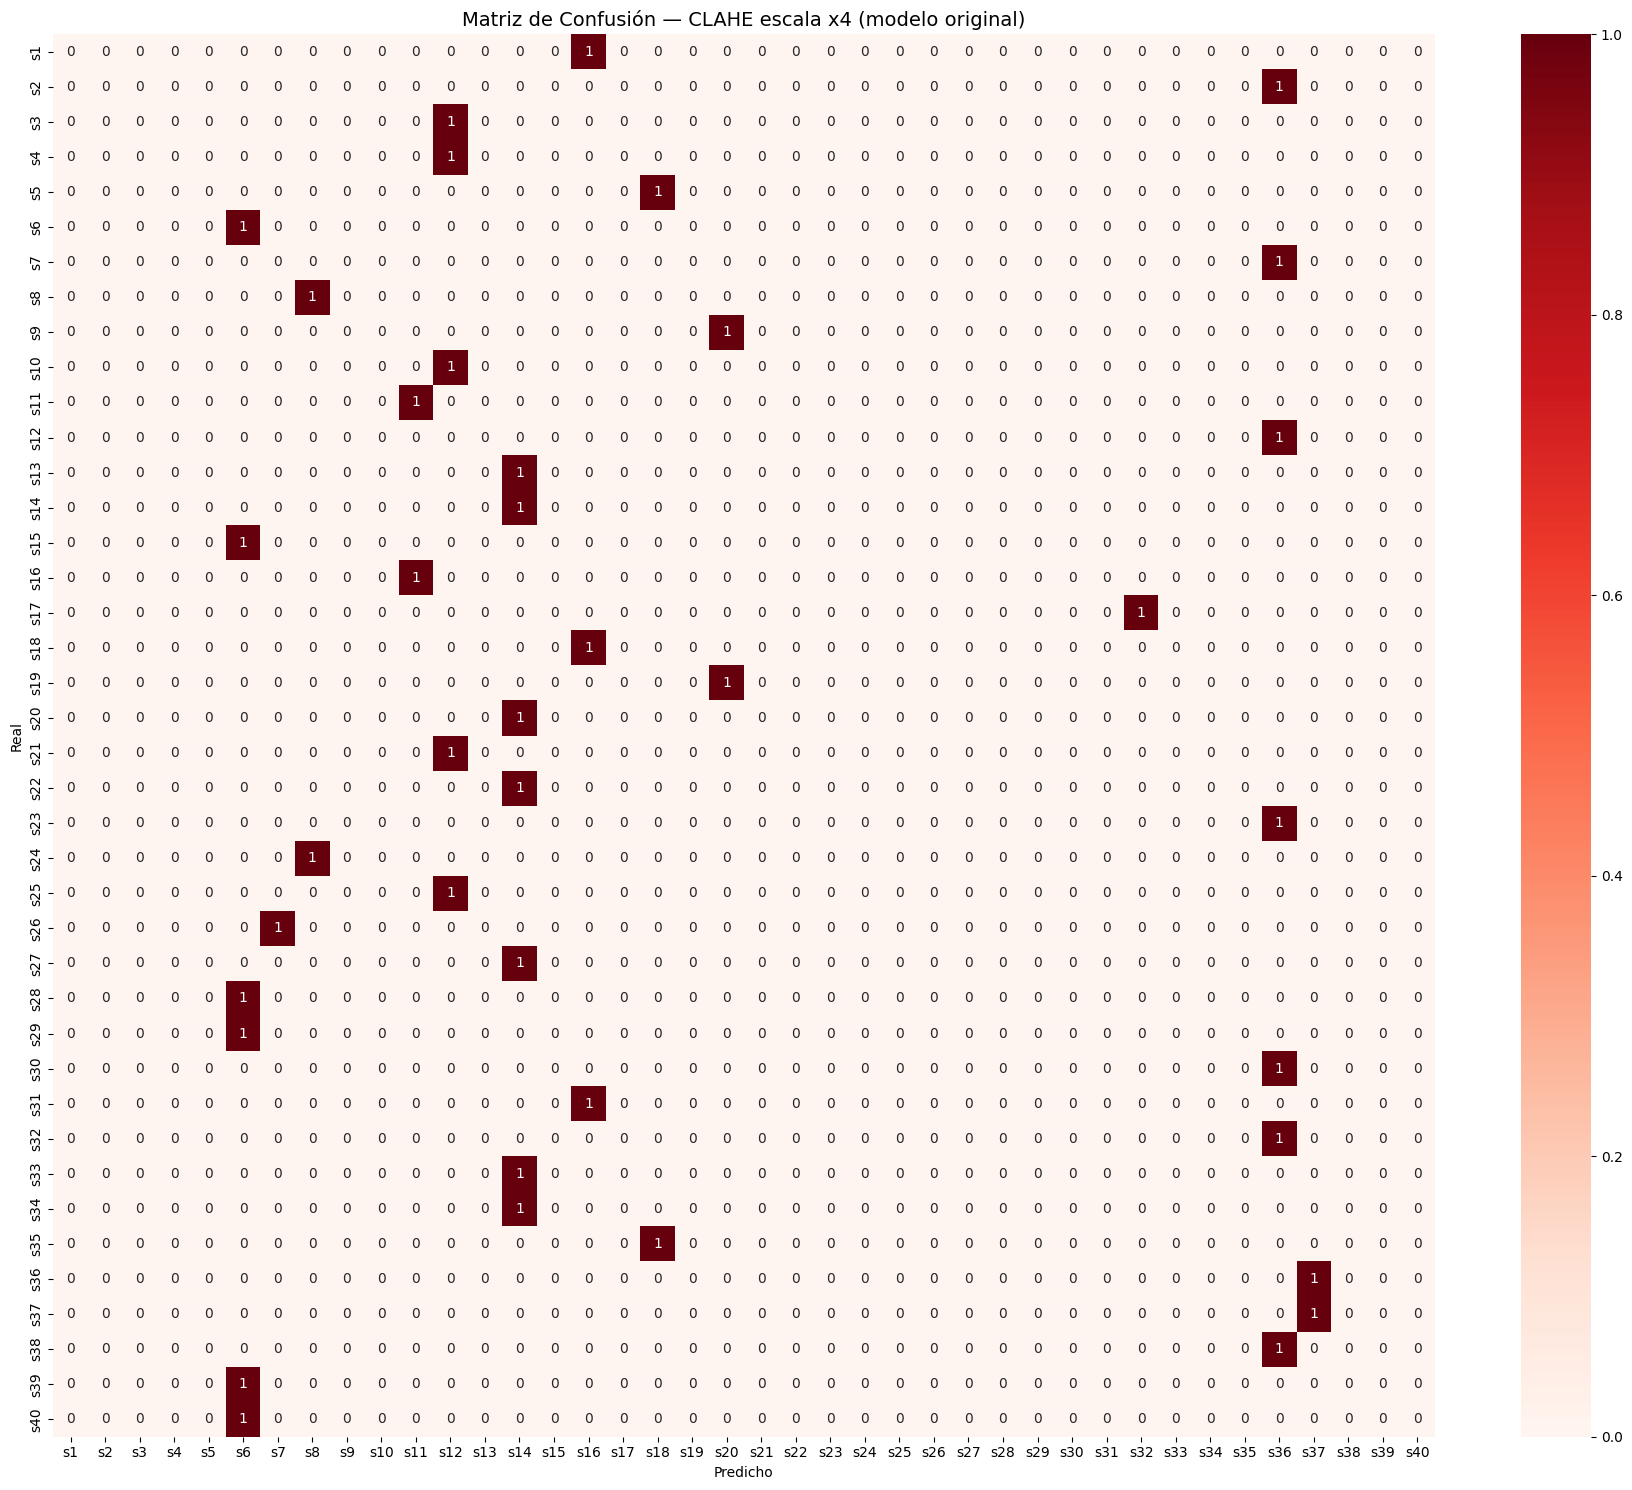

In [30]:
cm_clahe = confusion_matrix(all_labels_clahe, all_preds_clahe)

plt.figure(figsize=(18, 15))
sns.heatmap(cm_clahe, annot=True, fmt='d', cmap='Reds',
            xticklabels=[f"s{i+1}" for i in range(NUM_CLASSES)],
            yticklabels=[f"s{i+1}" for i in range(NUM_CLASSES)])
plt.title('Matriz de Confusión — CLAHE escala x4 (modelo original)', fontsize=14)
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.tight_layout()
plt.show()

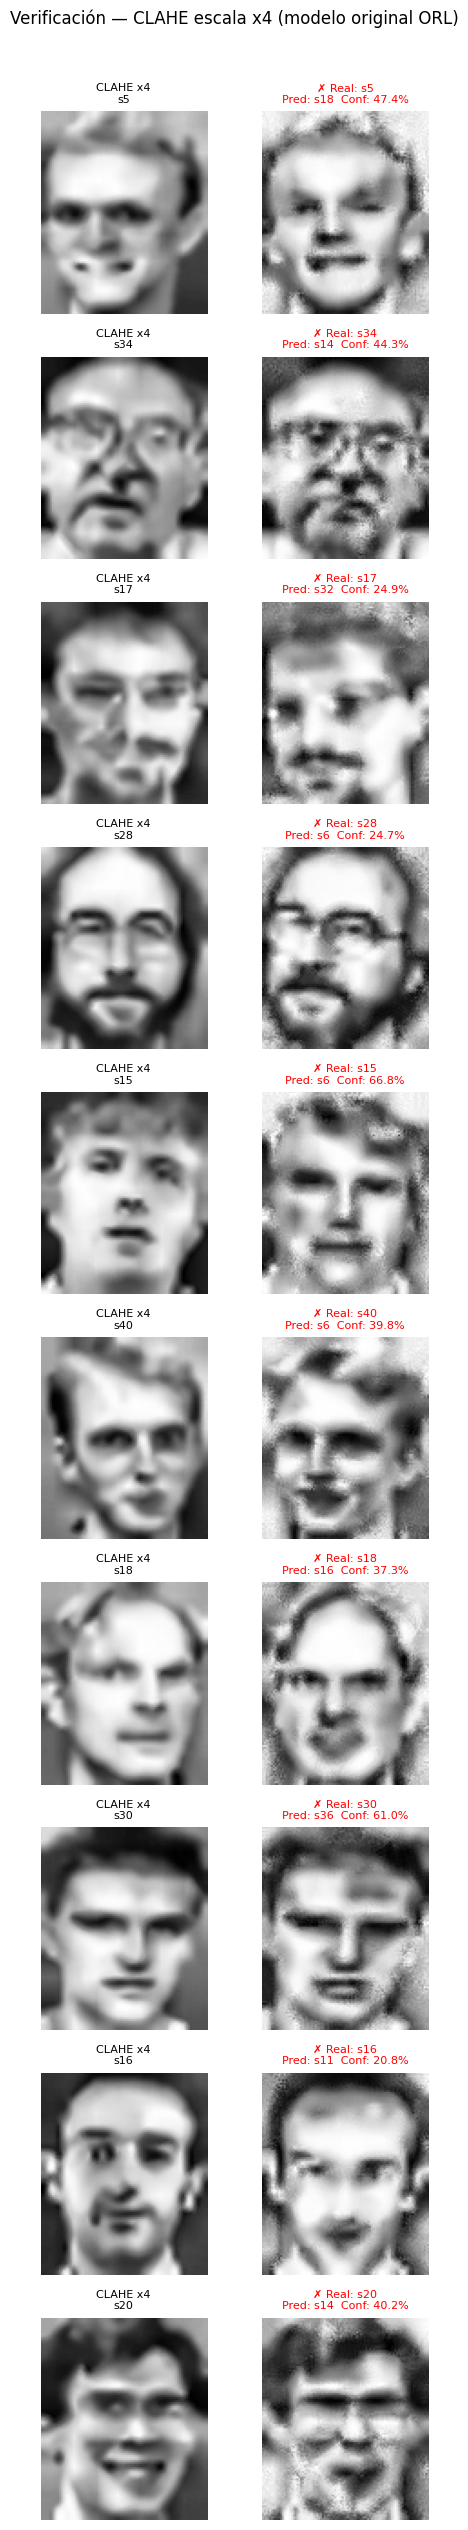

In [31]:
def plot_verification_clahe(ref_dataset, test_dataset, model, n=10, escala="x4"):
    """
    Columna izquierda : imagen CLAHE training (referencia)
    Columna derecha   : imagen CLAHE testing  + resultado
    """
    model.eval()

    # Referencia: primera imagen por sujeto del training CLAHE
    train_reference = {}
    for img, label in ref_dataset:
        if label not in train_reference:
            train_reference[label] = img

    indices = np.random.choice(len(test_dataset), n, replace=False)

    fig, axes = plt.subplots(n, 2, figsize=(5, n * 2.5))
    fig.suptitle(f"Verificación — CLAHE escala {escala} (modelo original ORL)",
                 fontsize=12, y=1.01)

    def denorm(t):
        return (t.squeeze().cpu().numpy() * 0.5 + 0.5).clip(0, 1)

    with torch.no_grad():
        for row, idx in enumerate(indices):
            img_test, label = test_dataset[idx]
            logits = model(img_test.unsqueeze(0).to(DEVICE))
            probs  = torch.softmax(logits, dim=1)
            conf, pred = probs.max(1)
            pred = pred.item()
            conf = conf.item() * 100

            correct = (pred == label)
            color   = 'green' if correct else 'red'
            symbol  = '✓' if correct else '✗'

            axes[row, 0].imshow(denorm(train_reference[label]), cmap='gray')
            axes[row, 0].set_title(f"CLAHE {escala}\ns{label+1}", fontsize=8)
            axes[row, 0].axis('off')

            axes[row, 1].imshow(denorm(img_test), cmap='gray')
            axes[row, 1].set_title(
                f"{symbol} Real: s{label+1}\nPred: s{pred+1}  Conf: {conf:.1f}%",
                fontsize=8, color=color
            )
            axes[row, 1].axis('off')

    plt.tight_layout()
    plt.show()

plot_verification_clahe(clahe_train_dataset, clahe_test_dataset, model, n=10, escala="x4")

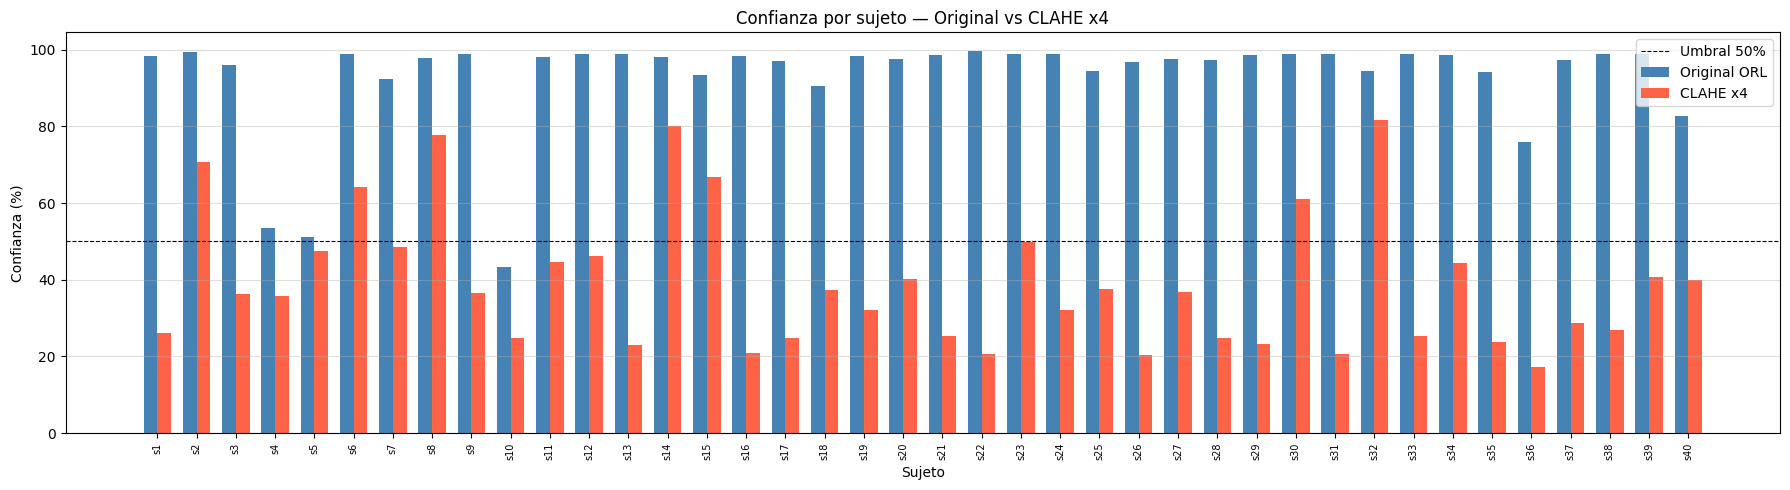

In [32]:
# Confianzas del modelo original (calculadas antes)
confs_original = []
model.eval()
with torch.no_grad():
    for img_test, label in test_dataset:
        logits = model(img_test.unsqueeze(0).to(DEVICE))
        probs  = torch.softmax(logits, dim=1)
        conf, _ = probs.max(1)
        confs_original.append(conf.item() * 100)

confs_original = np.array(confs_original)
subjects = [f"s{i+1}" for i in range(NUM_CLASSES)]

x = np.arange(NUM_CLASSES)
width = 0.35

fig, ax = plt.subplots(figsize=(18, 5))
ax.bar(x - width/2, confs_original,   width, label='Original ORL', color='steelblue')
ax.bar(x + width/2, all_confs_clahe * 100, width, label='CLAHE x4',     color='tomato')

ax.set_xlabel('Sujeto')
ax.set_ylabel('Confianza (%)')
ax.set_title('Confianza por sujeto — Original vs CLAHE x4')
ax.set_xticks(x)
ax.set_xticklabels(subjects, rotation=90, fontsize=7)
ax.axhline(y=50, color='black', linestyle='--', linewidth=0.8, label='Umbral 50%')
ax.legend()
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

In [33]:
clahe_train_transform = transforms.Compose([
    transforms.Resize((IMG_HEIGHT, IMG_WIDTH)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

clahe_test_transform = transforms.Compose([
    transforms.Resize((IMG_HEIGHT, IMG_WIDTH)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

clahe_train_dataset_v2 = ORLDataset(CLAHE_TRAIN_PATH, transform=clahe_train_transform)
clahe_test_dataset_v2  = ORLDataset(CLAHE_TEST_PATH,  transform=clahe_test_transform)

clahe_train_loader_v2 = DataLoader(clahe_train_dataset_v2, batch_size=BATCH_SIZE,
                                    shuffle=True,  num_workers=0)
clahe_test_loader_v2  = DataLoader(clahe_test_dataset_v2,  batch_size=BATCH_SIZE,
                                    shuffle=False, num_workers=0)

print(f"Train CLAHE x4: {len(clahe_train_dataset_v2)} imágenes")
print(f"Test  CLAHE x4: {len(clahe_test_dataset_v2)}  imágenes")


Cargando desde : dataset/CLAHE/Training_CLAHE_escala4
Sujetos encontrados: 40
Total imágenes  : 360

Cargando desde : dataset/CLAHE/Testing_CLAHE_escala4
Sujetos encontrados: 40
Total imágenes  : 40
Train CLAHE x4: 360 imágenes
Test  CLAHE x4: 40  imágenes


In [34]:
# Instanciar modelo nuevo (no usar el entrenado con ORL original)
model_clahe = MobileFaceNet(num_classes=NUM_CLASSES).to(DEVICE)

criterion_clahe = nn.CrossEntropyLoss()

optimizer_clahe = optim.Adam(model_clahe.parameters(), lr=LEARNING_RATE)

scheduler_clahe = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_clahe,
    mode='min',
    factor=0.5,
    patience=5,
    min_lr=1e-6
)

print("Modelo CLAHE x4 inicializado correctamente.")

# Verificar shape
dummy = torch.zeros(1, 1, IMG_HEIGHT, IMG_WIDTH).to(DEVICE)
out   = model_clahe(dummy)
print(f"Shape de salida: {out.shape}")

Modelo CLAHE x4 inicializado correctamente.
Shape de salida: torch.Size([1, 40])


In [35]:
history_clahe = {'train_loss': [], 'train_acc': [],
                 'val_loss':   [], 'val_acc':   []}

best_val_acc_clahe = 0.0
patience_count     = 0
EARLY_STOP         = 10

print("="*60)
print("  Entrenando MobileFaceNet con CLAHE x4")
print("="*60)

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch(model_clahe, clahe_train_loader_v2,
                                       optimizer_clahe, criterion_clahe)
    va_loss, va_acc = evaluate(model_clahe, clahe_test_loader_v2,
                                criterion_clahe)

    scheduler_clahe.step(va_loss)
    current_lr = optimizer_clahe.param_groups[0]['lr']

    history_clahe['train_loss'].append(tr_loss)
    history_clahe['train_acc'].append(tr_acc)
    history_clahe['val_loss'].append(va_loss)
    history_clahe['val_acc'].append(va_acc)

    print(f"Época {epoch:02d}/{EPOCHS} | "
          f"Train Loss: {tr_loss:.4f}  Acc: {tr_acc*100:.2f}% | "
          f"Val Loss: {va_loss:.4f}  Acc: {va_acc*100:.2f}% | "
          f"LR: {current_lr:.2e}")

    if va_acc > best_val_acc_clahe:
        best_val_acc_clahe = va_acc
        torch.save(model_clahe.state_dict(), "best_mobilefacenet_clahe_x4.pth")
        print(f"  ✓ Mejor modelo guardado (val_acc={best_val_acc_clahe*100:.2f}%)")
        patience_count = 0
    else:
        patience_count += 1
        if patience_count >= EARLY_STOP:
            print(f"\nEarly stopping en época {epoch}")
            break

print(f"\nMejor Val Accuracy CLAHE x4: {best_val_acc_clahe*100:.2f}%")

  Entrenando MobileFaceNet con CLAHE x4
Época 01/50 | Train Loss: 3.8779  Acc: 1.94% | Val Loss: 3.7964  Acc: 2.50% | LR: 1.00e-03
  ✓ Mejor modelo guardado (val_acc=2.50%)
Época 02/50 | Train Loss: 3.4014  Acc: 14.44% | Val Loss: 3.3863  Acc: 5.00% | LR: 1.00e-03
  ✓ Mejor modelo guardado (val_acc=5.00%)
Época 03/50 | Train Loss: 2.5406  Acc: 35.83% | Val Loss: 3.4387  Acc: 7.50% | LR: 1.00e-03
  ✓ Mejor modelo guardado (val_acc=7.50%)
Época 04/50 | Train Loss: 1.8177  Acc: 57.78% | Val Loss: 2.9777  Acc: 15.00% | LR: 1.00e-03
  ✓ Mejor modelo guardado (val_acc=15.00%)
Época 05/50 | Train Loss: 1.2350  Acc: 74.44% | Val Loss: 2.5788  Acc: 27.50% | LR: 1.00e-03
  ✓ Mejor modelo guardado (val_acc=27.50%)
Época 06/50 | Train Loss: 0.7924  Acc: 90.56% | Val Loss: 2.6675  Acc: 32.50% | LR: 1.00e-03
  ✓ Mejor modelo guardado (val_acc=32.50%)
Época 07/50 | Train Loss: 0.5718  Acc: 92.78% | Val Loss: 2.5881  Acc: 27.50% | LR: 1.00e-03
Época 08/50 | Train Loss: 0.4106  Acc: 94.72% | Val Loss: 

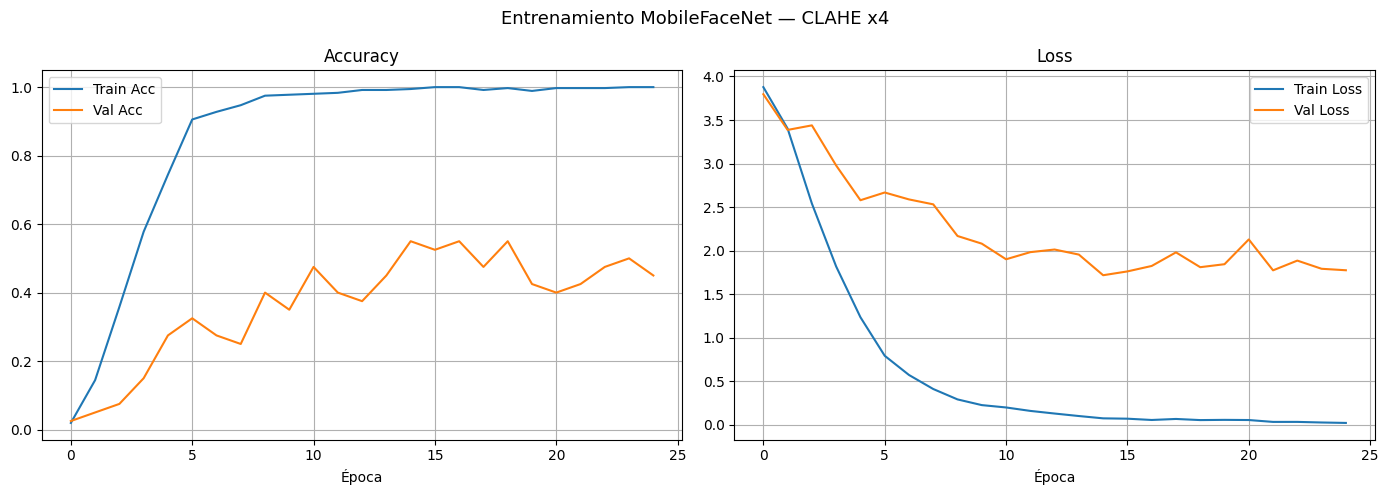

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Entrenamiento MobileFaceNet — CLAHE x4", fontsize=13)

axes[0].plot(history_clahe['train_acc'], label='Train Acc')
axes[0].plot(history_clahe['val_acc'],   label='Val Acc')
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Época')
axes[0].legend(); axes[0].grid(True)

axes[1].plot(history_clahe['train_loss'], label='Train Loss')
axes[1].plot(history_clahe['val_loss'],   label='Val Loss')
axes[1].set_title('Loss')
axes[1].set_xlabel('Época')
axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.show()

In [37]:
# Cargar mejor modelo CLAHE x4
model_clahe.load_state_dict(torch.load("best_mobilefacenet_clahe_x4.pth",
                                        map_location=DEVICE))
model_clahe.eval()

all_preds_clahe_v2, all_labels_clahe_v2, all_confs_clahe_v2 = [], [], []

with torch.no_grad():
    for imgs, labels in clahe_test_loader_v2:
        imgs   = imgs.to(DEVICE)
        logits = model_clahe(imgs)
        probs  = torch.softmax(logits, dim=1)
        conf, pred = probs.max(1)
        all_preds_clahe_v2.extend(pred.cpu().numpy())
        all_labels_clahe_v2.extend(labels.numpy())
        all_confs_clahe_v2.extend(conf.cpu().numpy())

all_preds_clahe_v2  = np.array(all_preds_clahe_v2)
all_labels_clahe_v2 = np.array(all_labels_clahe_v2)
all_confs_clahe_v2  = np.array(all_confs_clahe_v2)

acc_clahe_v2 = (all_preds_clahe_v2 == all_labels_clahe_v2).mean() * 100

print(f"\n{'='*55}")
print(f"  Accuracy Original  (ORL)              : 100.00%")
print(f"  Accuracy CLAHE x4  (sin reentrenar)   :  12.50%")
print(f"  Accuracy CLAHE x4  (reentrenado)      :  {acc_clahe_v2:.2f}%")
print(f"{'='*55}")
print(f"\n  Confianza promedio : {all_confs_clahe_v2.mean()*100:.2f}%")
print(f"  Confianza mínima   : {all_confs_clahe_v2.min()*100:.2f}%")
print(f"  Confianza máxima   : {all_confs_clahe_v2.max()*100:.2f}%")
print(f"  Desviación estándar: {all_confs_clahe_v2.std()*100:.2f}%")

print("\nClassification Report (CLAHE x4 reentrenado):")
print(classification_report(
    all_labels_clahe_v2, all_preds_clahe_v2,
    target_names=[f"s{i+1}" for i in range(NUM_CLASSES)],
    zero_division=0
))


  Accuracy Original  (ORL)              : 100.00%
  Accuracy CLAHE x4  (sin reentrenar)   :  12.50%
  Accuracy CLAHE x4  (reentrenado)      :  55.00%

  Confianza promedio : 54.49%
  Confianza mínima   : 24.68%
  Confianza máxima   : 92.75%
  Desviación estándar: 19.30%

Classification Report (CLAHE x4 reentrenado):
              precision    recall  f1-score   support

          s1       0.00      0.00      0.00         1
          s2       1.00      1.00      1.00         1
          s3       0.50      1.00      0.67         1
          s4       1.00      1.00      1.00         1
          s5       0.00      0.00      0.00         1
          s6       0.50      1.00      0.67         1
          s7       0.00      0.00      0.00         1
          s8       1.00      1.00      1.00         1
          s9       1.00      1.00      1.00         1
         s10       0.00      0.00      0.00         1
         s11       1.00      1.00      1.00         1
         s12       1.00      1.0

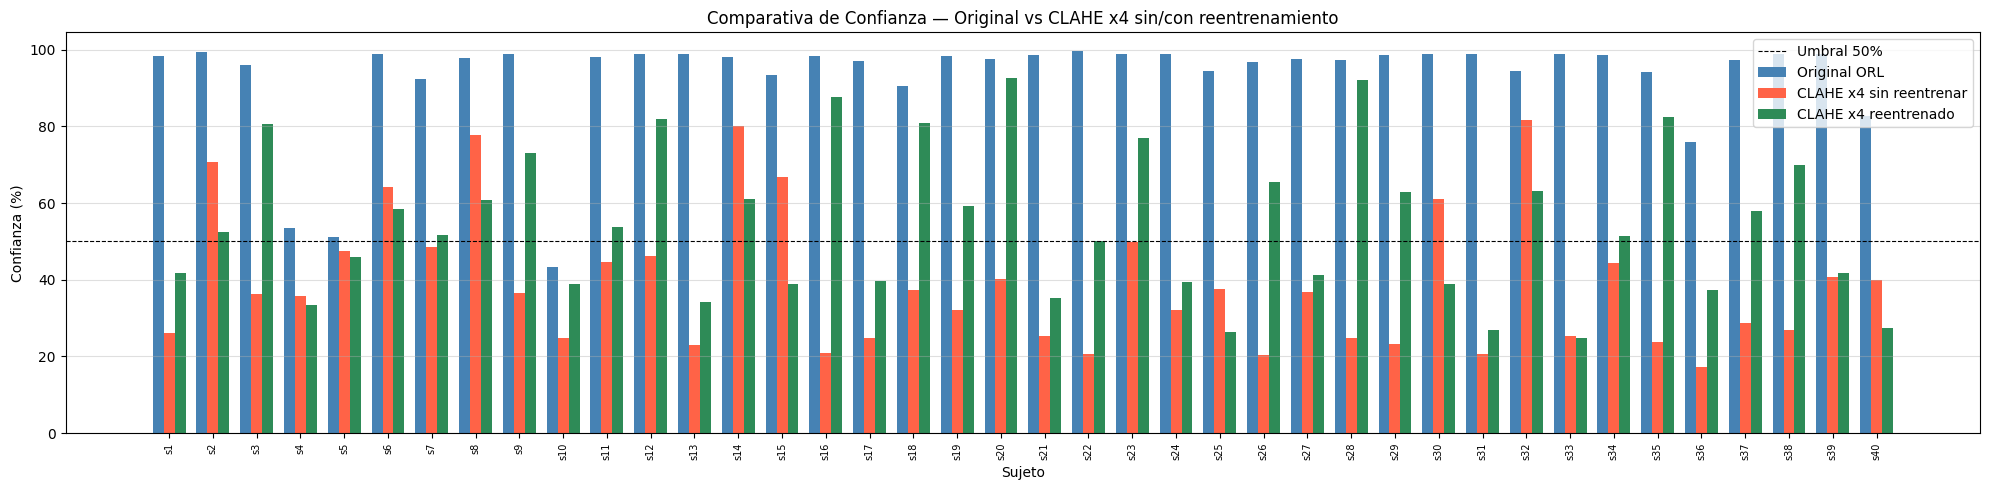

In [38]:
# Confianzas originales (ya calculadas antes como confs_original)
x     = np.arange(NUM_CLASSES)
width = 0.25

fig, ax = plt.subplots(figsize=(20, 5))
ax.bar(x - width,     confs_original,          width, label='Original ORL',          color='steelblue')
ax.bar(x,             all_confs_clahe * 100,   width, label='CLAHE x4 sin reentrenar', color='tomato')
ax.bar(x + width,     all_confs_clahe_v2 * 100, width, label='CLAHE x4 reentrenado',  color='seagreen')

ax.set_xlabel('Sujeto')
ax.set_ylabel('Confianza (%)')
ax.set_title('Comparativa de Confianza — Original vs CLAHE x4 sin/con reentrenamiento')
ax.set_xticks(x)
ax.set_xticklabels([f"s{i+1}" for i in range(NUM_CLASSES)], rotation=90, fontsize=7)
ax.axhline(y=50, color='black', linestyle='--', linewidth=0.8, label='Umbral 50%')
ax.legend()
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

In [48]:
class ORLDataset1(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.images = []
        self.labels = []

        for subject_id in range(1, NUM_CLASSES + 1):
            subject_folder = os.path.join(root_dir, f"s{subject_id}")
            if not os.path.exists(subject_folder):
                continue
            for img_file in sorted(os.listdir(subject_folder)):
                if img_file.endswith(('.pgm', '.png', '.jpg')):
                    self.images.append(os.path.join(subject_folder, img_file))
                    self.labels.append(subject_id - 1)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = Image.open(self.images[idx]).convert('L')
        if self.transform:
            img = self.transform(img)
        else:
            img = transforms.ToTensor()(img)
        return img, self.labels[idx]

In [60]:
clahe_train_dataset_v2 = ORLDataset1(CLAHE_TRAIN_PATH, transform=clahe_train_transform)
clahe_test_dataset_v2  = ORLDataset1(CLAHE_TEST_PATH,  transform=clahe_test_transform)

clahe_train_loader_v2 = DataLoader(clahe_train_dataset_v2, batch_size=BATCH_SIZE,
                                    shuffle=True,  num_workers=0, pin_memory=True)
clahe_test_loader_v2  = DataLoader(clahe_test_dataset_v2,  batch_size=BATCH_SIZE,
                                    shuffle=False, num_workers=0, pin_memory=True)

print(f"Train CLAHE x4: {len(clahe_train_dataset_v2)} imágenes")
print(f"Test  CLAHE x4: {len(clahe_test_dataset_v2)} imágenes")

Train CLAHE x4: 360 imágenes
Test  CLAHE x4: 40 imágenes


In [68]:
class ConvBN(nn.Module):
    def __init__(self, in_c, out_c, kernel, stride=1, padding=0, groups=1):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_c, out_c, kernel, stride=stride,
                      padding=padding, groups=groups, bias=False),
            nn.BatchNorm2d(out_c),
            nn.PReLU(out_c)   # PReLU por canal en lugar de ReLU
        )
    def forward(self, x):
        return self.conv(x)

class DepthwiseBN(nn.Module):
    def __init__(self, channels, stride=1):
        super().__init__()
        self.dw = nn.Sequential(
            nn.Conv2d(channels, channels, 3, stride=stride,
                      padding=1, groups=channels, bias=False),
            nn.BatchNorm2d(channels),
            nn.PReLU(channels)
        )
    def forward(self, x):
        return self.dw(x)

class Bottleneck(nn.Module):
    def __init__(self, in_c, out_c, stride, expansion):
        super().__init__()
        mid_c = in_c * expansion
        self.block = nn.Sequential(
            # Expand
            nn.Conv2d(in_c, mid_c, 1, bias=False),
            nn.BatchNorm2d(mid_c),
            nn.PReLU(mid_c),
            # Depthwise
            nn.Conv2d(mid_c, mid_c, 3, stride=stride,
                      padding=1, groups=mid_c, bias=False),
            nn.BatchNorm2d(mid_c),
            nn.PReLU(mid_c),
            # Project (sin activación al final)
            nn.Conv2d(mid_c, out_c, 1, bias=False),
            nn.BatchNorm2d(out_c),
        )
        self.use_residual = (stride == 1 and in_c == out_c)

    def forward(self, x):
        if self.use_residual:
            return x + self.block(x)
        return self.block(x)

In [71]:
import torch.nn.functional as F

class ArcFaceLoss(nn.Module):
    def __init__(self, in_features, num_classes, s=30.0, m=0.50):
        super().__init__()
        self.s = s
        self.m = m
        self.weight = nn.Parameter(torch.FloatTensor(num_classes, in_features))
        nn.init.xavier_uniform_(self.weight)

    def forward(self, embeddings, labels):
        emb_norm = F.normalize(embeddings, dim=1)
        w_norm   = F.normalize(self.weight, dim=1)

        cosine = F.linear(emb_norm, w_norm).clamp(-1 + 1e-7, 1 - 1e-7)
        theta  = torch.acos(cosine)

        target_logits = torch.cos(theta + self.m)

        one_hot = torch.zeros_like(cosine)
        one_hot.scatter_(1, labels.view(-1, 1), 1.0)

        output = self.s * (one_hot * target_logits + (1 - one_hot) * cosine)
        return F.cross_entropy(output, labels)

In [77]:
class MobileFaceNet2(nn.Module):
    """
    MobileFaceNet con PReLU + ArcFace
    El classifier se elimina — ArcFaceLoss lo reemplaza
    """
    def __init__(self, embedding_dim=128):
        super().__init__()

        # Stem con stride=1 en primera conv (fiel al paper)
        self.stem = nn.Sequential(
            ConvBN(1, 64, 3, stride=1, padding=1),   # stride=1, preserva resolución
            DepthwiseBN(64, stride=1)
        )

        cfg = [
            (2,  64,  5, 2),
            (4, 128,  1, 2),
            (2, 128,  6, 1),
            (4, 128,  1, 2),
            (2, 128,  2, 1),
        ]

        blocks = []
        in_c = 64
        for t, c, n, s in cfg:
            for i in range(n):
                stride = s if i == 0 else 1
                blocks.append(Bottleneck(in_c, c, stride, t))
                in_c = c
        self.bottlenecks = nn.Sequential(*blocks)

        self.conv_512 = ConvBN(128, 512, 1, padding=0)

        self.gdconv = nn.Sequential(
        nn.Conv2d(512, 512, kernel_size=(14, 12), groups=512, bias=False),
        nn.GroupNorm(num_groups=32, num_channels=512)
        )

        self.embedding = nn.Sequential(
            nn.Conv2d(512, embedding_dim, 1, bias=False),
            nn.GroupNorm(num_groups=8, num_channels=embedding_dim),
            nn.Flatten()
        )

        self.dropout = nn.Dropout(p=0.4)
        # Sin self.classifier — ArcFace lo maneja

    def forward(self, x):
        x = self.stem(x)
        x = self.bottlenecks(x)
        x = self.conv_512(x)
        x = self.gdconv(x)
        x = self.embedding(x)
        x = x.view(x.size(0), -1)
        x = self.dropout(x)
        return x   # retorna embedding 128-D normalizado
model = MobileFaceNet2().to(DEVICE)
print(model)

MobileFaceNet2(
  (stem): Sequential(
    (0): ConvBN(
      (conv): Sequential(
        (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (2): PReLU(num_parameters=64)
      )
    )
    (1): DepthwiseBN(
      (dw): Sequential(
        (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=64, bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (2): PReLU(num_parameters=64)
      )
    )
  )
  (bottlenecks): Sequential(
    (0): Bottleneck(
      (block): Sequential(
        (0): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (2): PReLU(num_parameters=128)
        (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(2, 2), pad

In [78]:
def train_one_epoch_arcface(model, arcface, loader, optimizer):
    model.train()
    arcface.train()
    total_loss, correct, total = 0.0, 0, 0

    for inputs, labels in loader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        embeddings = model(inputs)
        loss = arcface(embeddings, labels)
        loss.backward()
        optimizer.step()

        # Accuracy aproximada durante entrenamiento
        with torch.no_grad():
            emb_n = F.normalize(embeddings, dim=1)
            w_n   = F.normalize(arcface.weight, dim=1)
            logits = F.linear(emb_n, w_n)
            _, predicted = logits.max(1)
            correct += predicted.eq(labels).sum().item()
            total   += labels.size(0)

        total_loss += loss.item()

    return total_loss / len(loader), correct / total


def evaluate_arcface(model, arcface, loader):
    model.eval()
    arcface.eval()
    total_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            embeddings = model(inputs)
            loss = arcface(embeddings, labels)

            emb_n  = F.normalize(embeddings, dim=1)
            w_n    = F.normalize(arcface.weight, dim=1)
            logits = F.linear(emb_n, w_n)
            _, predicted = logits.max(1)
            correct += predicted.eq(labels).sum().item()
            total   += labels.size(0)
            total_loss += loss.item()

    return total_loss / len(loader), correct / total

In [79]:
# Cargar pesos ORL (solo el backbone, sin classifier)
model_ft2 = MobileFaceNet2(embedding_dim=128).to(DEVICE)

# Cargar pesos compatibles del modelo ORL original
# (se ignoran las capas que no existen: classifier)
orl_state = torch.load("best_mobilefacenet_orl.pth", map_location=DEVICE)
model_state = model_ft2.state_dict()

pretrained = {k: v for k, v in orl_state.items()
              if k in model_state and model_state[k].shape == v.shape}

model_state.update(pretrained)
model_ft2.load_state_dict(model_state)

loaded = len(pretrained)
total  = len(model_state)
print(f"Pesos cargados: {loaded}/{total} capas transferidas desde ORL")

arcface = ArcFaceLoss(in_features=128, num_classes=NUM_CLASSES,
                      s=30.0, m=0.50).to(DEVICE)

optimizer_ft2 = optim.SGD([
    {'params': model_ft2.stem.parameters(),        'lr': 1e-4},
    {'params': model_ft2.bottlenecks.parameters(), 'lr': 1e-4},
    {'params': model_ft2.conv_512.parameters(),    'lr': 5e-4},
    {'params': model_ft2.gdconv.parameters(),      'lr': 5e-4},
    {'params': model_ft2.embedding.parameters(),   'lr': 5e-4},
    {'params': arcface.parameters(),               'lr': 1e-3},
], momentum=0.9, weight_decay=4e-5)

scheduler_ft2 = optim.lr_scheduler.CosineAnnealingLR(
    optimizer_ft2, T_max=60, eta_min=1e-7
)

EPOCHS_FT2    = 60
EARLY_STOP_FT = 15
best_val_acc  = 0.0
patience_count = 0
history_ft2   = {'train_loss': [], 'train_acc': [],
                 'val_loss':   [], 'val_acc':   []}

print("="*60)
print("  Experimento 4 — Fine-tuning con PReLU + ArcFace")
print("="*60)

for epoch in range(1, EPOCHS_FT2 + 1):
    tr_loss, tr_acc = train_one_epoch_arcface(model_ft2, arcface,
                                               clahe_train_loader_v2,
                                               optimizer_ft2)
    va_loss, va_acc = evaluate_arcface(model_ft2, arcface,
                                        clahe_test_loader_v2)
    scheduler_ft2.step()

    history_ft2['train_loss'].append(tr_loss)
    history_ft2['train_acc'].append(tr_acc)
    history_ft2['val_loss'].append(va_loss)
    history_ft2['val_acc'].append(va_acc)

    current_lr = optimizer_ft2.param_groups[0]['lr']
    print(f"Época {epoch:02d}/{EPOCHS_FT2} | "
          f"Train Loss: {tr_loss:.4f}  Acc: {tr_acc*100:.2f}% | "
          f"Val Loss: {va_loss:.4f}  Acc: {va_acc*100:.2f}% | "
          f"LR: {current_lr:.2e}")

    if va_acc > best_val_acc:
        best_val_acc = va_acc
        torch.save({
            'model': model_ft2.state_dict(),
            'arcface': arcface.state_dict()
        }, "best_mobilefacenet_arcface_clahe_x4.pth")
        print(f"  ✓ Guardado (val_acc={best_val_acc*100:.2f}%)")
        patience_count = 0
    else:
        patience_count += 1
        if patience_count >= EARLY_STOP_FT:
            print(f"\nEarly stopping en época {epoch}")
            break

print(f"\nMejor Val Accuracy Experimento 4 (ArcFace): {best_val_acc*100:.2f}%")

Pesos cargados: 5/327 capas transferidas desde ORL
  Experimento 4 — Fine-tuning con PReLU + ArcFace


c:\Users\LENOVO\Desktop\Universidad\Ciclo 8\Machine Learning\Mora_Abel_ML_Evaluacion1\Mora_Abel_face-recognition-ML\.venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Época 01/60 | Train Loss: 20.5673  Acc: 2.22% | Val Loss: 19.8428  Acc: 2.50% | LR: 9.99e-05
  ✓ Guardado (val_acc=2.50%)
Época 02/60 | Train Loss: 19.6198  Acc: 5.83% | Val Loss: 18.5827  Acc: 2.50% | LR: 9.97e-05
Época 03/60 | Train Loss: 19.3422  Acc: 3.61% | Val Loss: 18.4391  Acc: 5.00% | LR: 9.94e-05
  ✓ Guardado (val_acc=5.00%)
Época 04/60 | Train Loss: 18.8651  Acc: 5.00% | Val Loss: 18.1113  Acc: 10.00% | LR: 9.89e-05
  ✓ Guardado (val_acc=10.00%)
Época 05/60 | Train Loss: 18.7585  Acc: 5.56% | Val Loss: 18.0340  Acc: 5.00% | LR: 9.83e-05
Época 06/60 | Train Loss: 18.3968  Acc: 7.50% | Val Loss: 17.8466  Acc: 5.00% | LR: 9.76e-05
Época 07/60 | Train Loss: 18.0623  Acc: 10.00% | Val Loss: 17.6005  Acc: 10.00% | LR: 9.67e-05
Época 08/60 | Train Loss: 17.9574  Acc: 10.28% | Val Loss: 17.4033  Acc: 12.50% | LR: 9.57e-05
  ✓ Guardado (val_acc=12.50%)
Época 09/60 | Train Loss: 17.6774  Acc: 12.78% | Val Loss: 17.1840  Acc: 12.50% | LR: 9.46e-05
Época 10/60 | Train Loss: 17.4507  Acc

In [80]:
# Cargar mejor modelo ArcFace
model_ft2.load_state_dict(
    torch.load("best_mobilefacenet_arcface_clahe_x4.pth", map_location=DEVICE)['model']
)
model_ft2.eval()
arcface.load_state_dict(
    torch.load("best_mobilefacenet_arcface_clahe_x4.pth", map_location=DEVICE)['arcface']
)
arcface.eval()

all_preds, all_labels, all_confs = [], [], []

with torch.no_grad():
    w_norm = F.normalize(arcface.weight, dim=1)
    for imgs, labels in clahe_test_loader_v2:
        imgs = imgs.to(DEVICE)
        emb  = model_ft2(imgs)
        emb_norm = F.normalize(emb, dim=1)
        logits   = F.linear(emb_norm, w_norm)
        probs    = torch.softmax(logits * arcface.s, dim=1)
        conf, pred = probs.max(1)
        all_preds.extend(pred.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_confs.extend(conf.cpu().numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_confs  = np.array(all_confs)

print(f"\n{'='*55}")
print(f"  Accuracy CLAHE x4 (ArcFace + PReLU) : {(all_preds == all_labels).mean()*100:.2f}%")
print(f"  Confianza promedio : {all_confs.mean()*100:.2f}%")
print(f"  Confianza mínima   : {all_confs.min()*100:.2f}%")
print(f"  Confianza máxima   : {all_confs.max()*100:.2f}%")
print(f"  Desviación estándar: {all_confs.std()*100:.2f}%")
print(f"{'='*55}\n")

print("Classification Report (Experimento 4 — ArcFace):")
print(classification_report(
    all_labels, all_preds,
    target_names=[f"s{i+1}" for i in range(NUM_CLASSES)]
))


  Accuracy CLAHE x4 (ArcFace + PReLU) : 85.00%
  Confianza promedio : 86.70%
  Confianza mínima   : 35.33%
  Confianza máxima   : 100.00%
  Desviación estándar: 19.90%

Classification Report (Experimento 4 — ArcFace):
              precision    recall  f1-score   support

          s1       0.00      0.00      0.00         1
          s2       1.00      1.00      1.00         1
          s3       1.00      1.00      1.00         1
          s4       1.00      1.00      1.00         1
          s5       0.50      1.00      0.67         1
          s6       1.00      1.00      1.00         1
          s7       1.00      1.00      1.00         1
          s8       1.00      1.00      1.00         1
          s9       1.00      1.00      1.00         1
         s10       0.00      0.00      0.00         1
         s11       1.00      1.00      1.00         1
         s12       1.00      1.00      1.00         1
         s13       0.50      1.00      0.67         1
         s14       1.00 

c:\Users\LENOVO\Desktop\Universidad\Ciclo 8\Machine Learning\Mora_Abel_ML_Evaluacion1\Mora_Abel_face-recognition-ML\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\LENOVO\Desktop\Universidad\Ciclo 8\Machine Learning\Mora_Abel_ML_Evaluacion1\Mora_Abel_face-recognition-ML\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\LENOVO\Desktop\Universidad\Ciclo 8\Machine Learning\Mora_Abel_ML_Evaluacion1\Mora_Abel_face-recognition-ML\.venv\Lib\site-packages\sklearn\metrics\_c

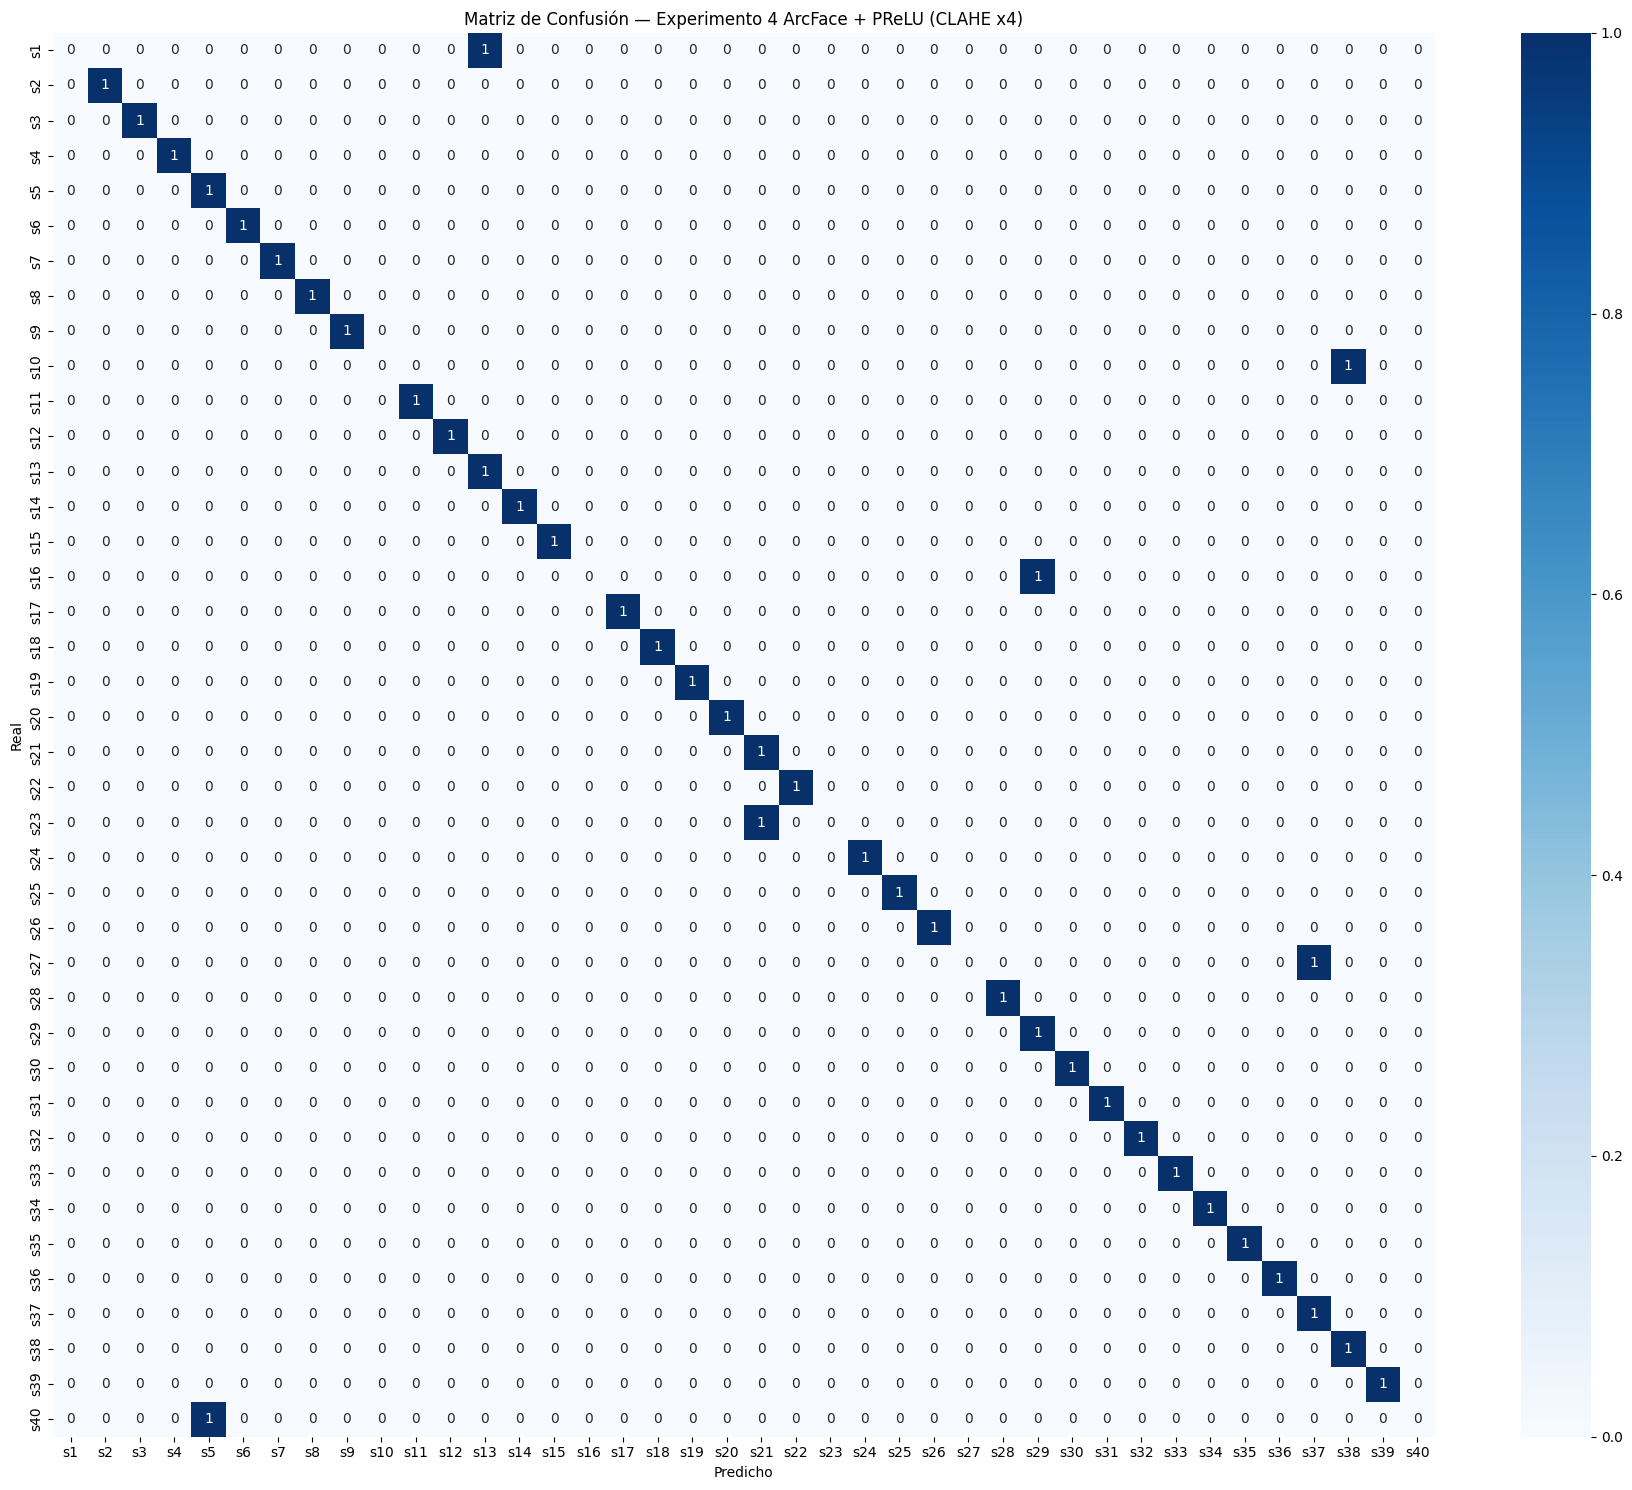

In [81]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(18, 15))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[f"s{i+1}" for i in range(NUM_CLASSES)],
            yticklabels=[f"s{i+1}" for i in range(NUM_CLASSES)])
plt.title('Matriz de Confusión — Experimento 4 ArcFace + PReLU (CLAHE x4)')
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.tight_layout()
plt.show()

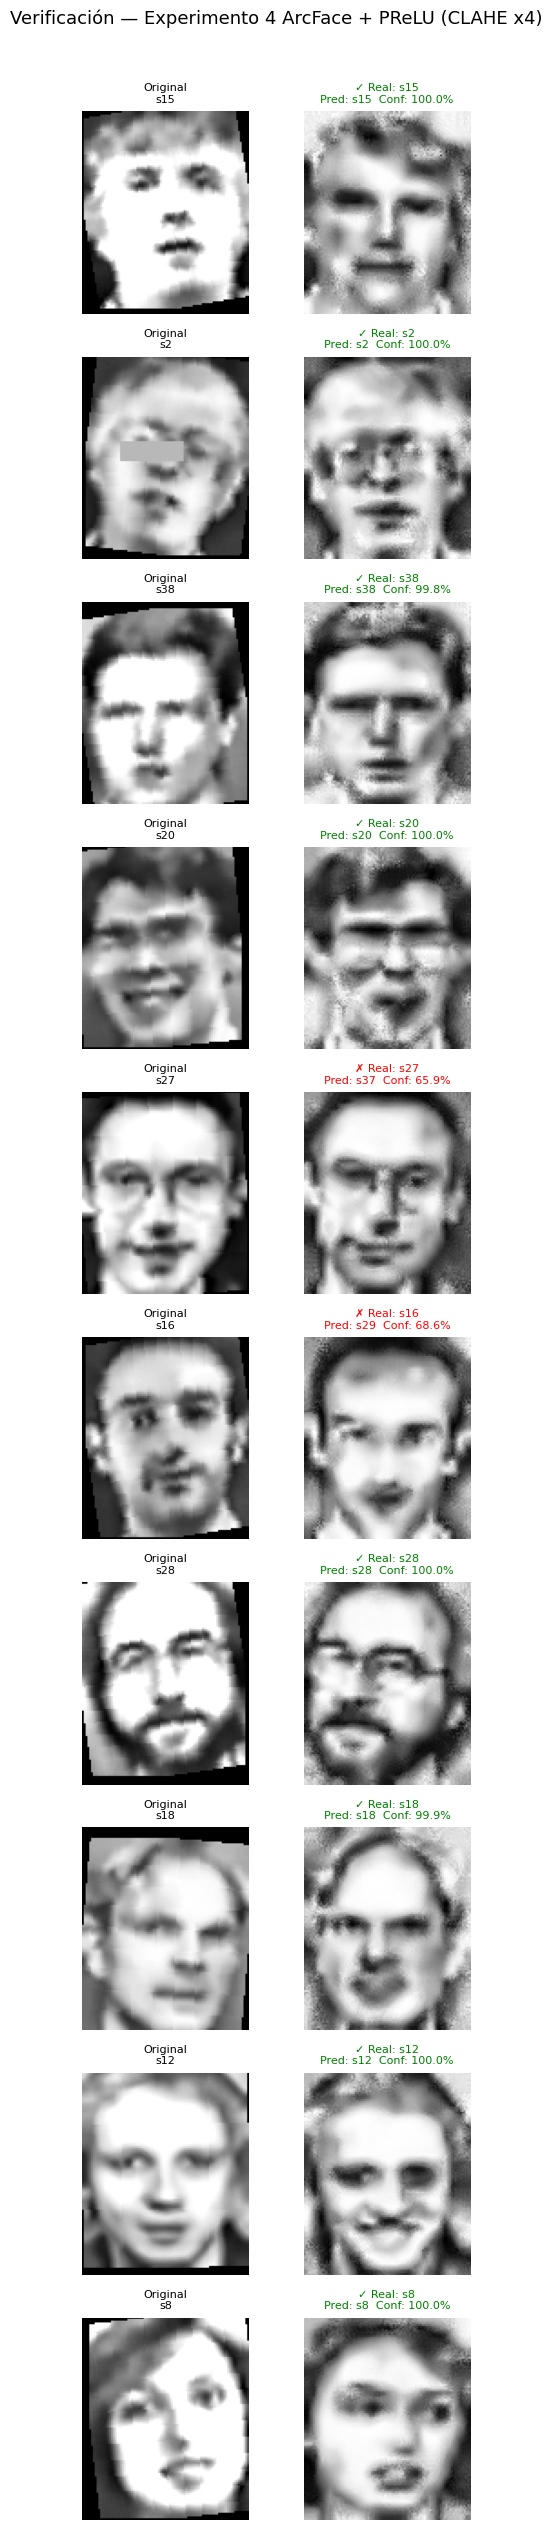


--- Resumen de verificación (ArcFace) ---
Identificados correctamente : 34/40
Accuracy total              : 85.00%
Confianza promedio          : 86.70%


In [82]:
def plot_verification_arcface(train_dataset, test_dataset, model, arcface, n=10):
    model.eval()
    arcface.eval()

    train_reference = {}
    for img, label in train_dataset:
        if label not in train_reference:
            train_reference[label] = img

    indices = np.random.choice(len(test_dataset), n, replace=False)

    fig, axes = plt.subplots(n, 2, figsize=(5, n * 2.5))
    fig.suptitle("Verificación — Experimento 4 ArcFace + PReLU (CLAHE x4)",
                 fontsize=13, y=1.01)

    w_norm = F.normalize(arcface.weight, dim=1)

    with torch.no_grad():
        for row, idx in enumerate(indices):
            img_test, label = test_dataset[idx]

            emb      = model(img_test.unsqueeze(0).to(DEVICE))
            emb_norm = F.normalize(emb, dim=1)
            logits   = F.linear(emb_norm, w_norm)
            probs    = torch.softmax(logits * arcface.s, dim=1)
            conf, pred = probs.max(1)
            pred     = pred.item()
            conf     = conf.item() * 100

            def denorm(t):
                return (t.squeeze().cpu().numpy() * 0.5 + 0.5).clip(0, 1)

            img_train_show = denorm(train_reference[label])
            img_test_show  = denorm(img_test)

            correct = (pred == label)
            color   = 'green' if correct else 'red'
            symbol  = '✓' if correct else '✗'

            axes[row, 0].imshow(img_train_show, cmap='gray')
            axes[row, 0].set_title(f"Original\ns{label+1}", fontsize=8)
            axes[row, 0].axis('off')

            axes[row, 1].imshow(img_test_show, cmap='gray')
            axes[row, 1].set_title(
                f"{symbol} Real: s{label+1}\nPred: s{pred+1}  Conf: {conf:.1f}%",
                fontsize=8, color=color
            )
            axes[row, 1].axis('off')

    plt.tight_layout()
    plt.show()

    # Resumen numérico
    correct_total = 0
    confs_all = []
    with torch.no_grad():
        for img_test, label in test_dataset:
            emb      = model(img_test.unsqueeze(0).to(DEVICE))
            emb_norm = F.normalize(emb, dim=1)
            logits   = F.linear(emb_norm, w_norm)
            probs    = torch.softmax(logits * arcface.s, dim=1)
            conf, pred = probs.max(1)
            if pred.item() == label:
                correct_total += 1
            confs_all.append(conf.item() * 100)

    print("\n--- Resumen de verificación (ArcFace) ---")
    print(f"Identificados correctamente : {correct_total}/{len(test_dataset)}")
    print(f"Accuracy total              : {correct_total/len(test_dataset)*100:.2f}%")
    print(f"Confianza promedio          : {np.mean(confs_all):.2f}%")


plot_verification_arcface(clahe_train_dataset_v2, clahe_test_dataset_v2,
                           model_ft2, arcface, n=10)